# Smart Review Analyzer — Baseline Model

## Objective
The goal of this notebook is to build a baseline machine learning model for sentiment classification using TF-IDF features.

We will:
- Load precomputed TF-IDF vectors
- Split the dataset into training and testing sets
- Train a Logistic Regression model
- Evaluate its performance using multiple metrics
- Save the trained model

# **Import Libraries**

In [29]:
# Data handling
import pickle
import numpy as np

# Model & evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# **Load TF-IDF Data**

In [2]:
# Load data
with open("/content/tfidf_vectors.pkl", "rb") as f:
    data = pickle.load(f)

# Extract features and labels
X = data["X"]
y = data["y"]

print("Feature matrix shape:", X.shape)
print("Labels shape:", len(y))

Feature matrix shape: (49582, 5000)
Labels shape: 49582


# **Train-Test Split**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39665
Testing samples: 9917


# **Train Baseline Model (Logistic Regression)**

In [31]:
# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# **Make Predictions**

In [32]:
y_pred = model.predict(X_test)

# **Model Evaluation**

In [33]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8817182615710396

Classification Report:

              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4940
    positive       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



# **Confusion Matrix Visualization**

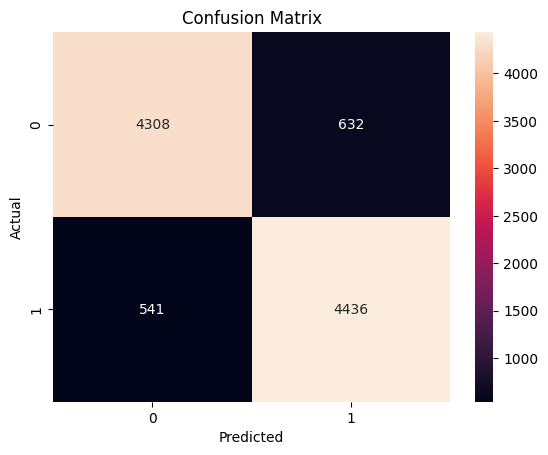

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Save the Trained Model**

In [17]:
with open("baseline_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as baseline_model.pkl")

Model saved as baseline_model.pkl
